# MAT204 – Mühendisler İçin Olasılık ve İstatistik
## Bölüm 6: Birlikte Dağılımlı Rastgele Değişkenler

**Dr. Haydar Kılıç — OSTİMTECH Mühendislik Fakültesi**

---

### İçindekiler
1. [Birleşik Dağılım Fonksiyonu (DDF)](#1)
2. [Ayrık Birleşik Dağılım — Çorap Örneği](#2)
3. [Marjinal ve Koşullu Dağılımlar (Ayrık)](#3)
4. [Sürekli Birleşik Dağılım](#4)
5. [Marjinal OYF Hesaplama](#5)
6. [Bağımsız Rastgele Değişkenler](#6)
7. [Bağımsız RDV Toplamı — Konvolüsyon](#7)
8. [Koşullu Dağılımlar: Ayrık Durum](#8)
9. [Koşullu Dağılımlar: Sürekli Durum](#9)
10. [Simülasyon ile Doğrulama](#10)

In [1]:
# ─── Gerekli kütüphaneler ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from fractions import Fraction
import itertools

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3
})
DARK_RED = '#8B0000'
print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


<a id='1'></a>
## 1. Birleşik Dağılım Fonksiyonu (DDF)

### Tanım
Bir çift rastgele değişkenimiz (ayrık veya sürekli) $X$ ve $Y$ var.  
$X$ ve $Y$'nin **birleşik kümülatif olasılık dağılım fonksiyonu**:

$$F_{X,Y}(x, y) = P[X \leq x,\; Y \leq y]$$

Geometrik yorum: $(X, Y)$ noktasının $(x, y)$ noktasının **güneybatısında** yer alma olasılığı.

### Temel Özellikler
| Özellik | Formül |
|---|---|
| Marjinal DDF — X | $F_X(x) = F_{X,Y}(x, \infty)$ |
| Marjinal DDF — Y | $F_Y(y) = F_{X,Y}(\infty, y)$ |
| Dikdörtgen olasılığı | $P(x_1 < X \leq x_2,\; y_1 < Y \leq y_2) = F(x_2,y_2)+F(x_1,y_1)-F(x_1,y_2)-F(x_2,y_1)$ |
| Birleşik olasılık | $P(X > x,\; Y > y) = 1 - F_X(x) - F_Y(y) + F_{X,Y}(x,y)$ |

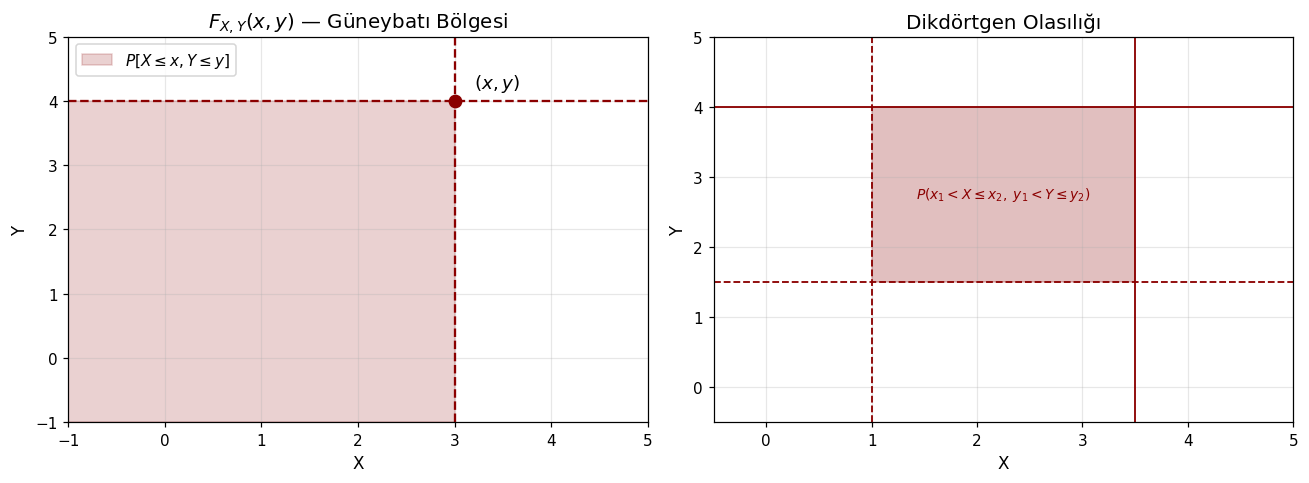

In [2]:
# ─── DDF'nin geometrik yorumu ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Sol: güneybatı bölgesi
ax = axes[0]
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.fill_between([-1, 3], [-1, -1], [4, 4], alpha=0.18, color=DARK_RED, label='$P[X\\leq x, Y\\leq y]$')
ax.axvline(3, color=DARK_RED, lw=1.5, ls='--')
ax.axhline(4, color=DARK_RED, lw=1.5, ls='--')
ax.plot(3, 4, 'o', color=DARK_RED, ms=8, zorder=5)
ax.annotate('$(x, y)$', (3, 4), (3.2, 4.2), fontsize=12)
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('$F_{X,Y}(x,y)$ — Güneybatı Bölgesi')
ax.legend(fontsize=10)

# Sağ: dikdörtgen olasılık
ax2 = axes[1]
ax2.set_xlim(-0.5, 5); ax2.set_ylim(-0.5, 5)
x1, x2, y1, y2 = 1, 3.5, 1.5, 4
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, color=DARK_RED, alpha=0.25)
ax2.add_patch(rect)
for xi, ls in zip([x1, x2], ['--', '-']):
    ax2.axvline(xi, color=DARK_RED, lw=1.2, ls=ls)
for yi, ls in zip([y1, y2], ['--', '-']):
    ax2.axhline(yi, color=DARK_RED, lw=1.2, ls=ls)
ax2.text((x1+x2)/2, (y1+y2)/2, '$P(x_1 < X \\leq x_2,\\; y_1 < Y \\leq y_2)$',
         ha='center', va='center', fontsize=9, color='darkred', fontweight='bold')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
ax2.set_title('Dikdörtgen Olasılığı')
plt.tight_layout()
plt.show()

<a id='2'></a>
## 2. Ayrık Birleşik Dağılım — Çorap Örneği

**Problem:** 12 renkli çorap dolu bir çekmeceden, **yerine koymadan** rastgele 2 çorap çekin:
- 6 siyah, 4 beyaz, 2 mor

$B$ = çekilen siyah çorap sayısı, $W$ = çekilen beyaz çorap sayısı

Birleşik PMF:
$$P(B=b,\; W=w) = \frac{\binom{6}{b}\binom{4}{w}\binom{2}{2-b-w}}{\binom{12}{2}}, \quad 0 \leq b, w \leq 2,\; b+w \leq 2$$

In [3]:
from math import comb

# ─── Birleşik PMF hesaplama ────────────────────────────────────────────────
total = comb(12, 2)  # = 66

joint_pmf = {}
for b in range(3):
    for w in range(3):
        purple = 2 - b - w
        if 0 <= purple <= 2:
            joint_pmf[(b, w)] = comb(6, b) * comb(4, w) * comb(2, purple) / total
        else:
            joint_pmf[(b, w)] = 0

# ─── Tablo görünümü ────────────────────────────────────────────────────────
print('=' * 55)
print(f"  Birleşik PMF  p_{{B,W}}(b,w)    [Toplam = {total}]")
print('=' * 55)
print(f"{'':>8}  W=0       W=1       W=2    | P(B=b)")
print('-' * 55)

for b in range(3):
    row = [joint_pmf[(b, w)] for w in range(3)]
    fracs = [Fraction(int(p*66), 66) for p in row]
    marginal_b = sum(row)
    print(f"  B={b}   {str(fracs[0]):>8}  {str(fracs[1]):>8}  {str(fracs[2]):>8}  | {Fraction(int(marginal_b*66),66)}")

print('-' * 55)
marginal_w = [sum(joint_pmf[(b, w)] for b in range(3)) for w in range(3)]
fracs_w = [Fraction(int(p*66), 66) for p in marginal_w]
print(f"P(W=w)  {str(fracs_w[0]):>8}  {str(fracs_w[1]):>8}  {str(fracs_w[2]):>8}  | 1")
print('=' * 55)

  Birleşik PMF  p_{B,W}(b,w)    [Toplam = 66]
          W=0       W=1       W=2    | P(B=b)
-------------------------------------------------------
  B=0       1/66      4/33      1/11  | 5/22
  B=1       2/11      4/11         0  | 6/11
  B=2       5/22         0         0  | 5/22
-------------------------------------------------------
P(W=w)     14/33     16/33      1/11  | 1


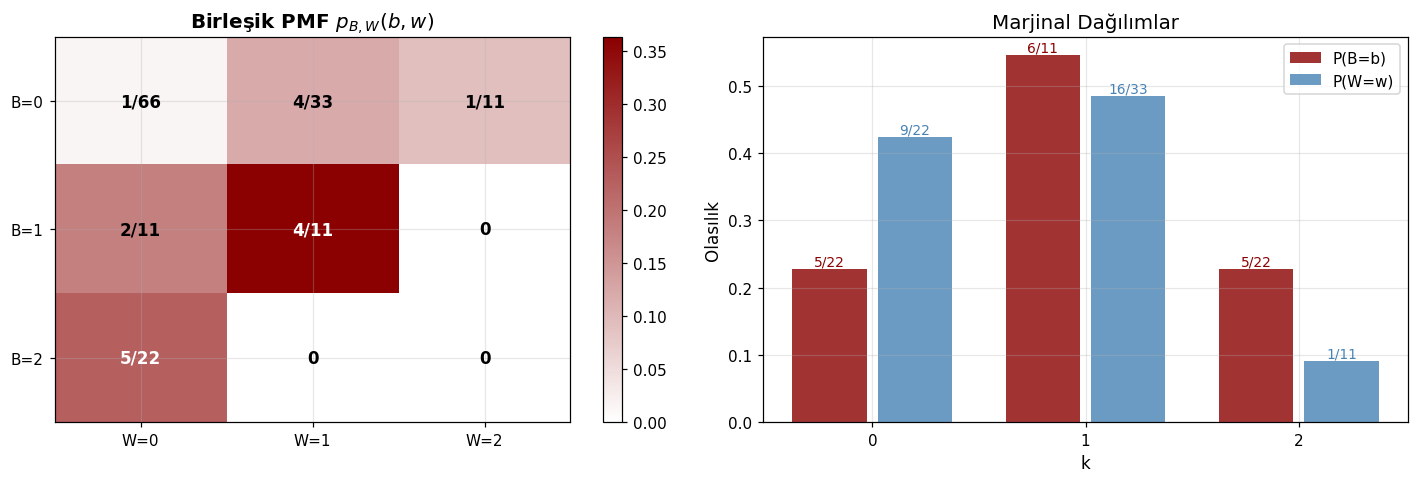

In [4]:
# ─── Isı haritası ile görselleştirme ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Birleşik PMF matrisi
matrix = np.array([[joint_pmf[(b, w)] for w in range(3)] for b in range(3)])
cmap = LinearSegmentedColormap.from_list('dr', ['white', DARK_RED])

im = axes[0].imshow(matrix, cmap=cmap, vmin=0, vmax=matrix.max(), aspect='auto')
for b in range(3):
    for w in range(3):
        val = Fraction(int(joint_pmf[(b,w)]*66), 66)
        axes[0].text(w, b, str(val), ha='center', va='center', fontsize=11,
                     color='white' if matrix[b,w] > 0.2 else 'black', fontweight='bold')
axes[0].set_xticks([0,1,2]); axes[0].set_xticklabels(['W=0','W=1','W=2'])
axes[0].set_yticks([0,1,2]); axes[0].set_yticklabels(['B=0','B=1','B=2'])
axes[0].set_title('Birleşik PMF $p_{B,W}(b,w)$', fontweight='bold')
plt.colorbar(im, ax=axes[0])

# Marjinal dağılımlar
marg_b = matrix.sum(axis=1)
marg_w = matrix.sum(axis=0)
x = np.arange(3)
axes[1].bar(x - 0.2, marg_b, 0.35, label='P(B=b)', color=DARK_RED, alpha=0.8)
axes[1].bar(x + 0.2, marg_w, 0.35, label='P(W=w)', color='steelblue', alpha=0.8)
for i in range(3):
    axes[1].text(i-0.2, marg_b[i]+0.005, f'{Fraction(int(marg_b[i]*66),66)}', ha='center', fontsize=9, color=DARK_RED)
    axes[1].text(i+0.2, marg_w[i]+0.005, f'{Fraction(int(marg_w[i]*66),66)}', ha='center', fontsize=9, color='steelblue')
axes[1].set_xticks(x); axes[1].set_xticklabels(['0', '1', '2'])
axes[1].set_xlabel('k'); axes[1].set_ylabel('Olasılık')
axes[1].set_title('Marjinal Dağılımlar')
axes[1].legend()
plt.tight_layout()
plt.show()

<a id='3'></a>
## 3. Marjinal ve Koşullu Dağılımlar (Ayrık)

### Marjinal PMF
$$P(X = x) = \sum_y P(X=x,\; Y=y)$$

### Koşullu PMF
$$p_{X|Y}(x|y) = P(X=x \mid Y=y) = \frac{P(X=x,\; Y=y)}{P(Y=y)} = \frac{\text{birleşik pmf}}{\text{marjinal pmf}}$$

Koşullu Dağılım: P(B = b | W = w)

W = 0  [P(W=0) = 14/33]:
  P(B=0 | W=0) = 1/28  ≈ 0.0357
  P(B=1 | W=0) = 3/7  ≈ 0.4286
  P(B=2 | W=0) = 15/28  ≈ 0.5357

W = 1  [P(W=1) = 16/33]:
  P(B=0 | W=1) = 1/4  ≈ 0.2500
  P(B=1 | W=1) = 3/4  ≈ 0.7500
  P(B=2 | W=1) = 0  ≈ 0.0000

W = 2  [P(W=2) = 1/11]:
  P(B=0 | W=2) = 1  ≈ 1.0000
  P(B=1 | W=2) = 0  ≈ 0.0000
  P(B=2 | W=2) = 0  ≈ 0.0000


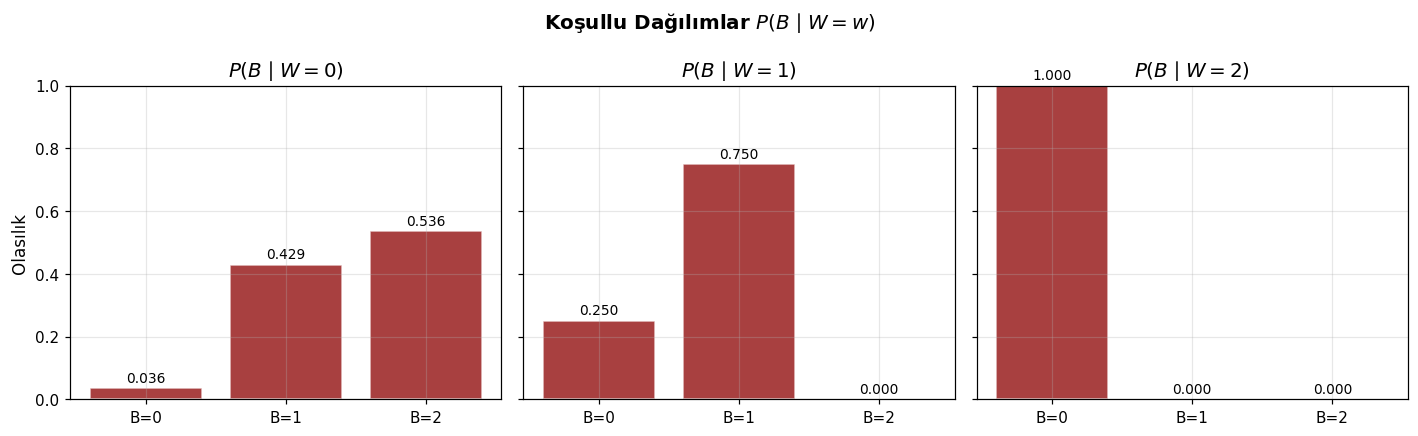

In [5]:
# ─── Koşullu dağılım hesaplama: P(B | W=w) ────────────────────────────────
print('Koşullu Dağılım: P(B = b | W = w)')
print('=' * 50)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for w_val in range(3):
    pW = sum(joint_pmf[(b, w_val)] for b in range(3))
    if pW == 0:
        continue
    cond = {b: joint_pmf[(b, w_val)] / pW for b in range(3)}

    print(f"\nW = {w_val}  [P(W={w_val}) = {Fraction(int(pW*66),66)}]:")
    for b in range(3):
        print(f"  P(B={b} | W={w_val}) = {Fraction(int(cond[b]*pW*66), int(pW*66)).limit_denominator(100)}  ≈ {cond[b]:.4f}")

    axes[w_val].bar(range(3), [cond[b] for b in range(3)],
                    color=DARK_RED, alpha=0.75, edgecolor='white')
    axes[w_val].set_xticks([0,1,2])
    axes[w_val].set_xticklabels(['B=0','B=1','B=2'])
    axes[w_val].set_title(f'$P(B \\mid W={w_val})$', fontweight='bold')
    axes[w_val].set_ylim(0, 1)
    for b in range(3):
        axes[w_val].text(b, cond[b]+0.02, f'{cond[b]:.3f}', ha='center', fontsize=9)

axes[0].set_ylabel('Olasılık')
plt.suptitle('Koşullu Dağılımlar $P(B \\mid W=w)$', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. Sürekli Birleşik Dağılım

### Tanım
Rastgele değişkenler $X$ ve $Y$, bir $f(x,y)$ fonksiyonu varsa **birlikte süreklidir**, öyle ki:
1. $f(x,y) \geq 0$ — negatif olmayan
2. $\int_{-\infty}^{\infty}\int_{-\infty}^{\infty} f(x,y)\,dx\,dy = 1$

### Ders Örneği — Düzgün Dağılım (Üçgen Bölge)

$$f(x,y) = \begin{cases} c & x \geq 0,\; y \geq 0,\; x+y \leq 3 \\ 0 & \text{aksi halde} \end{cases}$$

Normalizasyon: $c \times \frac{3 \times 3}{2} = 1 \implies c = \dfrac{2}{9}$

Normalizasyon kontrolü: ∫∫ f(x,y) dx dy = 1.000000  (Hata: 1.11e-14)
c = 2/9 = 0.222222


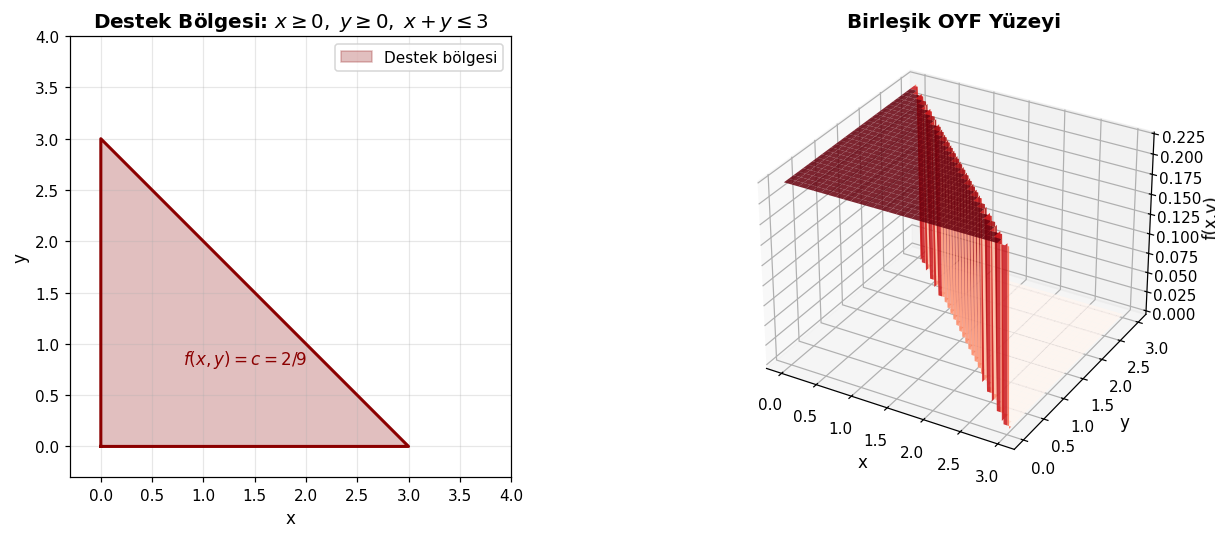

In [6]:
# ─── Düzgün dağılım — üçgen bölge ────────────────────────────────────────
c = 2/9  # normalizasyon sabiti

def f_joint(x, y):
    """f(x,y) = 2/9 üçgen bölgede, 0 dışında."""
    return np.where((x >= 0) & (y >= 0) & (x + y <= 3), c, 0.0)

# Normalizasyon doğrulama (sayısal)
from scipy.integrate import dblquad
result, error = dblquad(lambda y, x: f_joint(x, y), 0, 3, 0, lambda x: 3-x)
print(f'Normalizasyon kontrolü: ∫∫ f(x,y) dx dy = {result:.6f}  (Hata: {error:.2e})')
print(f'c = 2/9 = {2/9:.6f}')

# ─── 2D ve 3D görselleştirme ───────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))

# 2D: bölge
ax1 = fig.add_subplot(121)
triangle_x = [0, 3, 0, 0]
triangle_y = [0, 0, 3, 0]
ax1.fill(triangle_x, triangle_y, color=DARK_RED, alpha=0.25, label='Destek bölgesi')
ax1.plot(triangle_x, triangle_y, color=DARK_RED, lw=2)
ax1.text(0.8, 0.8, f'$f(x,y) = c = 2/9$', fontsize=11, color=DARK_RED)
ax1.set_xlim(-0.3, 4); ax1.set_ylim(-0.3, 4)
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('Destek Bölgesi: $x\\geq 0,\\; y\\geq 0,\\; x+y\\leq 3$', fontweight='bold')
ax1.legend()
ax1.set_aspect('equal')

# 3D: yoğunluk yüzeyi
ax2 = fig.add_subplot(122, projection='3d')
xv = np.linspace(0, 3, 60)
yv = np.linspace(0, 3, 60)
X2, Y2 = np.meshgrid(xv, yv)
Z2 = f_joint(X2, Y2)
ax2.plot_surface(X2, Y2, Z2, cmap='Reds', alpha=0.85, edgecolor='none')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('f(x,y)')
ax2.set_title('Birleşik OYF Yüzeyi', fontweight='bold')

plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. Marjinal OYF Hesaplama

### Formül
$$f_X(x) = \int_{-\infty}^{\infty} f(x,y)\,dy \qquad f_Y(y) = \int_{-\infty}^{\infty} f(x,y)\,dx$$

### Üçgen Bölge Örneği
X = x verildiğinde Y'nin aralığı $[0, 3-x]$'dir:

$$f_X(x) = \int_0^{3-x} \frac{2}{9}\,dy = \frac{2}{9}(3-x), \quad x \in [0,3]$$

### Ek Örnek: P(X < Y) hesabı
$$P(X < Y) = \iint_{x<y} f(x,y)\,dx\,dy = \int_0^{3/2} \int_x^{3-x} \frac{2}{9}\,dy\,dx = \frac{1}{2}$$

∫ f_X(x) dx = 1.000000  (= 1 olmalı)
P(X < Y) = 0.500000  (analitik = 0.5)


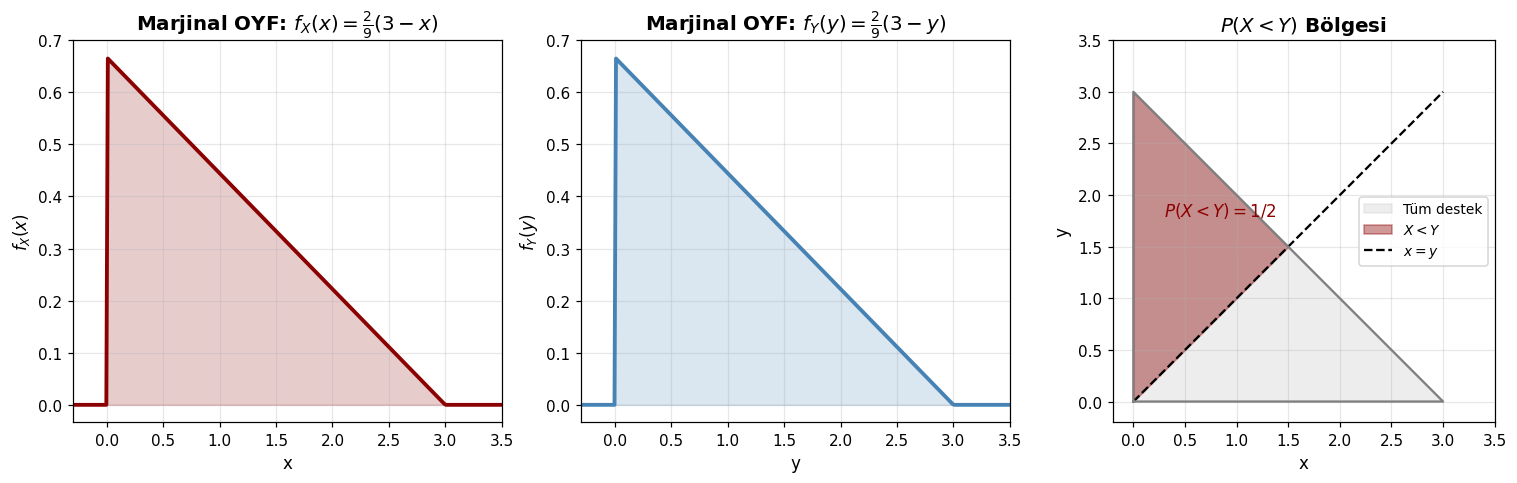

In [7]:
# ─── Marjinal OYF ─────────────────────────────────────────────────────────
def f_X(x):
    """Analitik marjinal: f_X(x) = (2/9)(3-x), x in [0,3]"""
    return np.where((x >= 0) & (x <= 3), (2/9)*(3 - x), 0.0)

def f_Y(y):
    """Simetri nedeniyle f_Y(y) = f_X(y)"""
    return np.where((y >= 0) & (y <= 3), (2/9)*(3 - y), 0.0)

# Sayısal doğrulama
from scipy.integrate import quad
I_fX, _ = quad(f_X, 0, 3)
print(f'∫ f_X(x) dx = {I_fX:.6f}  (= 1 olmalı)')

# P(X < Y) analitik = 1/2
P_XltY, _ = dblquad(lambda y, x: f_joint(x, y), 0, 1.5, lambda x: x, lambda x: 3-x)
print(f'P(X < Y) = {P_XltY:.6f}  (analitik = 0.5)')

# ─── Görselleştirme ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Marjinal f_X
xv = np.linspace(-0.5, 3.5, 300)
axes[0].plot(xv, f_X(xv), color=DARK_RED, lw=2.5)
axes[0].fill_between(np.linspace(0,3,200), f_X(np.linspace(0,3,200)), alpha=0.2, color=DARK_RED)
axes[0].set_title('Marjinal OYF: $f_X(x) = \\frac{2}{9}(3-x)$', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('$f_X(x)$')
axes[0].set_xlim(-0.3, 3.5)

# Marjinal f_Y
yv = np.linspace(-0.5, 3.5, 300)
axes[1].plot(yv, f_Y(yv), color='steelblue', lw=2.5)
axes[1].fill_between(np.linspace(0,3,200), f_Y(np.linspace(0,3,200)), alpha=0.2, color='steelblue')
axes[1].set_title('Marjinal OYF: $f_Y(y) = \\frac{2}{9}(3-y)$', fontweight='bold')
axes[1].set_xlabel('y'); axes[1].set_ylabel('$f_Y(y)$')
axes[1].set_xlim(-0.3, 3.5)

# P(X<Y) bölgesi
ax3 = axes[2]
xv2 = np.linspace(0, 3, 200)
ax3.fill(triangle_x, triangle_y, color='lightgray', alpha=0.4, label='Tüm destek')
# X < Y bölgesi (x=y doğrusunun üstü, üçgen içi)
xx = np.linspace(0, 1.5, 100)
ax3.fill_between(xx, xx, 3-xx, color=DARK_RED, alpha=0.4, label='$X < Y$')
ax3.plot([0, 3], [0, 3], 'k--', lw=1.5, label='$x = y$')
ax3.plot(triangle_x, triangle_y, color='gray', lw=1.5)
ax3.text(0.3, 1.8, '$P(X<Y) = 1/2$', fontsize=11, color=DARK_RED, fontweight='bold')
ax3.set_xlim(-0.2, 3.5); ax3.set_ylim(-0.2, 3.5)
ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.set_title('$P(X < Y)$ Bölgesi', fontweight='bold')
ax3.legend(fontsize=9)
ax3.set_aspect('equal')

plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. Bağımsız Rastgele Değişkenler

### Tanım
Rastgele değişkenler $X$ ve $Y$, herhangi bir gerçel $A, B \subset \mathbb{R}$ kümeleri için **bağımsızdır**:
$$P(X \in A,\; Y \in B) = P(X \in A) \cdot P(Y \in B)$$

$X$ ve $Y$ **ancak ve ancak** şu durumda bağımsızdır:

| Durum | Koşul |
|---|---|
| Genel | $F_{X,Y}(x,y) = F_X(x) \cdot F_Y(y)$ |
| Ayrık | $p_{X,Y}(x,y) = p_X(x) \cdot p_Y(y)$ |
| Sürekli | $f_{X,Y}(x,y) = f_X(x) \cdot f_Y(y)$ |

### Pratik Test
Eğer $f_{X,Y}(x,y) = g(x)\cdot h(y)$ biçiminde ayrışabiliyorsa → bağımsız!

> **Not:** Üçgen bölgedeki düzgün dağılım **bağımsız değildir** — çünkü destek bölgesi $x+y \leq 3$ kısıtı nedeniyle ayrışamaz.

In [8]:
# ─── Bağımsızlık testi: üçgen örnek bağımsız mı? ──────────────────────────
print('Bağımsızlık Testi — f(x,y) = f_X(x) * f_Y(y) mi?')
print('=' * 55)

test_pts = [(0.5, 0.5), (1.0, 1.0), (0.5, 1.5), (1.5, 0.5)]
for (x0, y0) in test_pts:
    joint   = f_joint(x0, y0)
    product = f_X(x0) * f_Y(y0)
    eq = '✓ eşit' if np.isclose(joint, product, atol=1e-9) else '✗ farklı'
    print(f'  x={x0}, y={y0}: f(x,y)={joint:.5f},  fX*fY={product:.5f}  → {eq}')

print()
print('Sonuç: Üçgen bölgedeki düzgün dağılım BAĞIMSIZ DEĞİLDİR.')
print('Sebep: Destek bölgesi x+y≤3, X ve Y değerlerini birbirine bağlar.')

# ─── Bağımsız olan örnek: Birim kare ──────────────────────────────────────
print()
print('Bağımsız Örnek: f(x,y) = 1, (x,y) ∈ [0,1]×[0,1]')
def f_ind(x, y):
    return np.where((0 <= x) & (x <= 1) & (0 <= y) & (y <= 1), 1.0, 0.0)

for (x0, y0) in [(0.3, 0.7), (0.5, 0.2), (0.8, 0.9)]:
    joint   = f_ind(x0, y0)
    fX_val  = 1.0 if 0 <= x0 <= 1 else 0.0
    fY_val  = 1.0 if 0 <= y0 <= 1 else 0.0
    product = fX_val * fY_val
    eq = '✓ eşit' if np.isclose(joint, product) else '✗ farklı'
    print(f'  x={x0}, y={y0}: f(x,y)={joint:.1f},  fX*fY={product:.1f}  → {eq}')

Bağımsızlık Testi — f(x,y) = f_X(x) * f_Y(y) mi?
  x=0.5, y=0.5: f(x,y)=0.22222,  fX*fY=0.30864  → ✗ farklı
  x=1.0, y=1.0: f(x,y)=0.22222,  fX*fY=0.19753  → ✗ farklı
  x=0.5, y=1.5: f(x,y)=0.22222,  fX*fY=0.18519  → ✗ farklı
  x=1.5, y=0.5: f(x,y)=0.22222,  fX*fY=0.18519  → ✗ farklı

Sonuç: Üçgen bölgedeki düzgün dağılım BAĞIMSIZ DEĞİLDİR.
Sebep: Destek bölgesi x+y≤3, X ve Y değerlerini birbirine bağlar.

Bağımsız Örnek: f(x,y) = 1, (x,y) ∈ [0,1]×[0,1]
  x=0.3, y=0.7: f(x,y)=1.0,  fX*fY=1.0  → ✓ eşit
  x=0.5, y=0.2: f(x,y)=1.0,  fX*fY=1.0  → ✓ eşit
  x=0.8, y=0.9: f(x,y)=1.0,  fX*fY=1.0  → ✓ eşit


Buluşma Problemi
X, Y ~ Uniform(0, 60) dakika, bağımsız
P(|X - Y| > 10) = ?

Analitik sonuç: P(|X-Y| > 10) = 25/36 ≈ 0.69444
Monte Carlo (1,000,000 örneklem): P(|X-Y| > 10) ≈ 0.69344
Hata: 0.00101


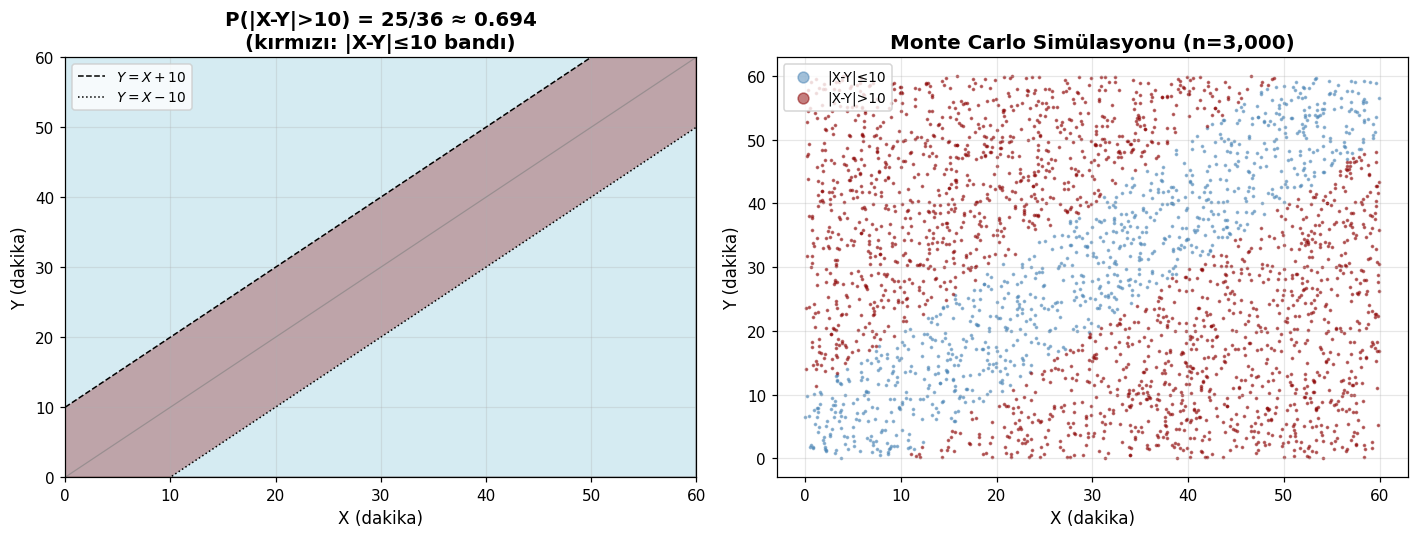

In [9]:
# ─── Buluşma Problemi (Ders Örneği) ───────────────────────────────────────
# Bir erkek ve kadın öğle 12-13 arasında bağımsız düzgün bir zamanda geliyor.
# P(|X - Y| > 10) = ?

print('Buluşma Problemi')
print('=' * 55)
print('X, Y ~ Uniform(0, 60) dakika, bağımsız')
print('P(|X - Y| > 10) = ?')
print()

# Analitik: 1 - (50/60)^2 = 1 - 25/36 = 11/36
# Ders notundaki P(ilk gelen 10 dakikadan fazla bekleme) = P(|X-Y|>10)
# = 1 - P(|X-Y| ≤ 10) = 1 - (bant alanı/toplam alan)
# Bant alanı: 60^2 - 2*(1/2)*(50^2) = 3600 - 2500 = 1100
# P = 2500/3600 = 25/36
analytic = 25/36
print(f'Analitik sonuç: P(|X-Y| > 10) = 25/36 ≈ {analytic:.5f}')

# Monte Carlo simülasyon
np.random.seed(42)
N = 1_000_000
X_sim = np.random.uniform(0, 60, N)
Y_sim = np.random.uniform(0, 60, N)
P_sim = np.mean(np.abs(X_sim - Y_sim) > 10)
print(f'Monte Carlo ({N:,} örneklem): P(|X-Y| > 10) ≈ {P_sim:.5f}')
print(f'Hata: {abs(P_sim - analytic):.5f}')

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Geometrik
ax = axes[0]
square = plt.Polygon([[0,0],[60,0],[60,60],[0,60]], fill=True,
                      facecolor='lightblue', edgecolor='gray', alpha=0.5)
ax.add_patch(square)
# |X-Y| ≤ 10 bandı
bant_x = [0, 50, 60, 60, 10, 0]
bant_y = [10, 60, 60, 50, 0, 0]
band = plt.Polygon(list(zip(bant_x, bant_y)), facecolor=DARK_RED, alpha=0.3)
ax.add_patch(band)
ax.plot([0,60],[10,70],'k--', lw=1, label='$Y=X+10$')
ax.plot([0,60],[-10,50],'k:', lw=1, label='$Y=X-10$')
ax.plot([0,60],[0,60],'gray', lw=0.8, ls='-', alpha=0.6)
ax.set_xlim(0,60); ax.set_ylim(0,60)
ax.set_xlabel('X (dakika)'); ax.set_ylabel('Y (dakika)')
ax.set_title(f'P(|X-Y|>10) = 25/36 ≈ {analytic:.3f}\n(kırmızı: |X-Y|≤10 bandı)', fontweight='bold')
ax.legend(fontsize=9)

# Simülasyon scatter
n_plot = 3000
idx = np.random.choice(N, n_plot, replace=False)
mask = np.abs(X_sim[idx] - Y_sim[idx]) > 10
axes[1].scatter(X_sim[idx][~mask], Y_sim[idx][~mask], s=2, color='steelblue', alpha=0.5, label='|X-Y|≤10')
axes[1].scatter(X_sim[idx][mask],  Y_sim[idx][mask],  s=2, color=DARK_RED, alpha=0.5, label='|X-Y|>10')
axes[1].set_xlabel('X (dakika)'); axes[1].set_ylabel('Y (dakika)')
axes[1].set_title(f'Monte Carlo Simülasyonu (n={n_plot:,})', fontweight='bold')
axes[1].legend(markerscale=5, fontsize=9)

plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Bağımsız RDV Toplamı — Konvolüsyon

### Sürekli Konvolüsyon Formülü
$X$ ve $Y$ bağımsız ise:
$$f_{X+Y}(z) = \int_{-\infty}^{\infty} f_X(x)\, f_Y(z-x)\,dx$$

### Bilinen Sonuçlar
| X | Y | X + Y |
|---|---|---|
| $\mathcal{N}(\mu_1, \sigma_1^2)$ | $\mathcal{N}(\mu_2, \sigma_2^2)$ | $\mathcal{N}(\mu_1+\mu_2, \sigma_1^2+\sigma_2^2)$ |
| $\text{Poi}(\lambda_1)$ | $\text{Poi}(\lambda_2)$ | $\text{Poi}(\lambda_1+\lambda_2)$ |
| $\text{Bin}(n_1,p)$ | $\text{Bin}(n_2,p)$ | $\text{Bin}(n_1+n_2,p)$ |

### Ders Örneği: Üçgensel Dağılım
$X, Y \sim \text{Unif}(0,1)$ bağımsız → $Z = X+Y$ üçgensel dağılım:
$$f_{X+Y}(z) = \begin{cases} z & 0 < z \leq 1 \\ 2-z & 1 < z < 2 \\ 0 & \text{aksi halde} \end{cases}$$

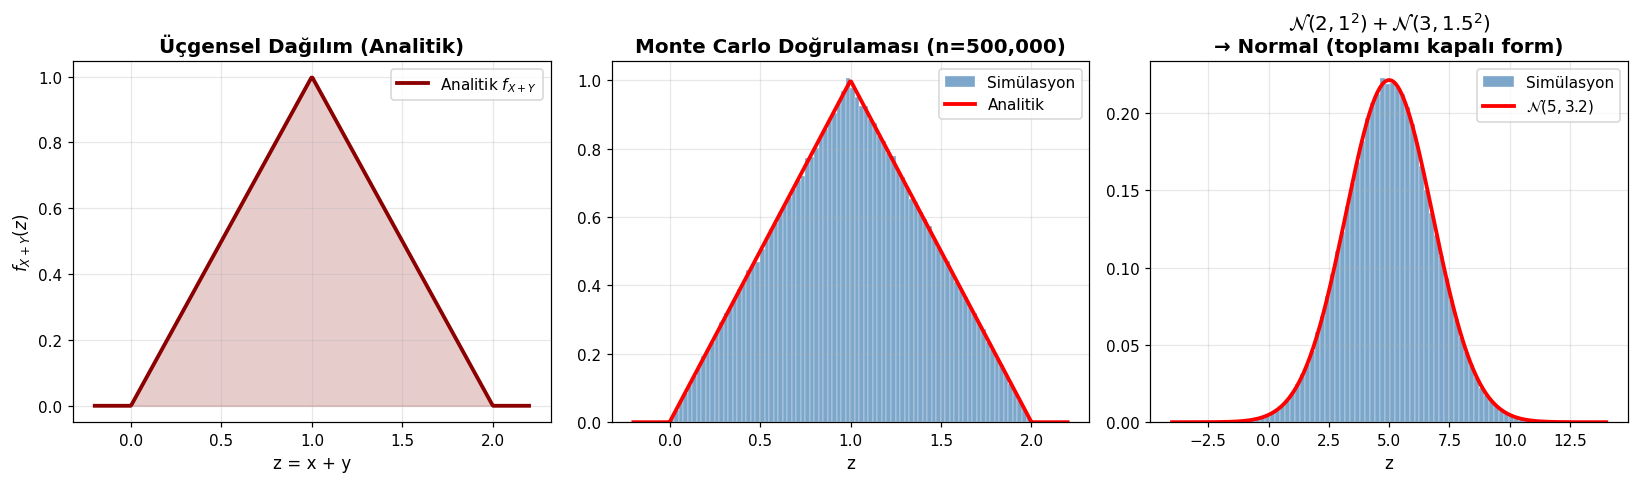

Üçgensel dağılım ortalama: E[Z] = 1.0008  (beklenen: 1.0)
Üçgensel dağılım varyans: Var[Z] = 0.1667  (beklenen: 1/6 ≈ 0.1667)


In [10]:
# ─── İki Uniform(0,1)'in Toplamı → Üçgensel Dağılım ──────────────────────
def f_triangle(z):
    z = np.asarray(z, dtype=float)
    out = np.zeros_like(z)
    out = np.where((z > 0) & (z <= 1), z, out)
    out = np.where((z > 1) & (z < 2), 2 - z, out)
    return out

# Monte Carlo doğrulama
np.random.seed(0)
N = 500_000
Z_sim = np.random.uniform(0, 1, N) + np.random.uniform(0, 1, N)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Analitik OYF
zv = np.linspace(-0.2, 2.2, 400)
axes[0].plot(zv, f_triangle(zv), color=DARK_RED, lw=2.5, label='Analitik $f_{X+Y}$')
axes[0].fill_between(np.linspace(0,2,400), f_triangle(np.linspace(0,2,400)),
                     alpha=0.2, color=DARK_RED)
axes[0].set_title('Üçgensel Dağılım (Analitik)', fontweight='bold')
axes[0].set_xlabel('z = x + y'); axes[0].set_ylabel('$f_{X+Y}(z)$')
axes[0].legend()

# Simülasyon histogramı
axes[1].hist(Z_sim, bins=80, density=True, color='steelblue', alpha=0.7,
             edgecolor='white', lw=0.3, label='Simülasyon')
axes[1].plot(zv, f_triangle(zv), 'r-', lw=2.5, label='Analitik')
axes[1].set_title(f'Monte Carlo Doğrulaması (n={N:,})', fontweight='bold')
axes[1].set_xlabel('z'); axes[1].legend()

# Normal toplamı
mu1, sig1 = 2, 1
mu2, sig2 = 3, 1.5
Z_norm = np.random.normal(mu1, sig1, N) + np.random.normal(mu2, sig2, N)
zn = np.linspace(-4, 14, 400)
f_sum = stats.norm.pdf(zn, mu1+mu2, np.sqrt(sig1**2+sig2**2))
axes[2].hist(Z_norm, bins=80, density=True, color='steelblue', alpha=0.7,
             edgecolor='white', lw=0.3, label='Simülasyon')
axes[2].plot(zn, f_sum, 'r-', lw=2.5,
             label=f'$\\mathcal{{N}}({mu1+mu2}, {sig1**2+sig2**2:.1f})$')
axes[2].set_title(f'$\\mathcal{{N}}({mu1},{sig1}^2)+\\mathcal{{N}}({mu2},{sig2}^2)$\n→ Normal (toplamı kapalı form)', fontweight='bold')
axes[2].set_xlabel('z'); axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Üçgensel dağılım ortalama: E[Z] = {Z_sim.mean():.4f}  (beklenen: 1.0)')
print(f'Üçgensel dağılım varyans: Var[Z] = {Z_sim.var():.4f}  (beklenen: 1/6 ≈ {1/6:.4f})')

<a id='8'></a>
## 8. Koşullu Dağılımlar: Ayrık Durum

### Tanım
$X$ ve $Y$ ayrık rastgele değişkenler ise:
$$p_{X|Y}(x|y) = P(X=x \mid Y=y) = \frac{p(x,y)}{p_Y(y)}, \quad p_Y(y) > 0$$

### Ders Örneği — Top Çekme
5 beyaz, 8 kırmızı top içeren torbadan yerine koymadan 3 top.  
$X_i = 1$ eğer $i$'inci beyaz top seçilirse, $0$ aksi halde ($i = 1, 2$).

In [11]:
# ─── Top çekme örneği: birleşik PMF ───────────────────────────────────────
total_balls = comb(13, 3)

# p(x1, x2): birleşik PMF
# x1=1 → beyaz top 1 seçildi, x2=1 → beyaz top 2 seçildi
# p(0,0): her ikisi de seçilmedi — kalan 11'den 3
# p(1,1): her ikisi seçildi — kalan 11'den 1
# p(0,1)=p(1,0): tam biri seçildi — kalan 11'den 2, beyaz top 1'den

p00 = comb(11, 3) * comb(2, 0) / total_balls
p11 = comb(11, 1) * comb(2, 2) / total_balls
p01 = comb(11, 2) * comb(2, 1) / total_balls
p10 = p01  # simetri

joint_balls = {(0,0): p00, (0,1): p01, (1,0): p10, (1,1): p11}

print('Birleşik PMF p(x1, x2):')
print('=' * 45)
for (x1, x2), p in joint_balls.items():
    f = Fraction(int(p * total_balls), int(total_balls)).limit_denominator(100)
    print(f'  p({x1},{x2}) = {f} = {p:.5f}')

# Koşullu dağılımlar
pX2_1 = sum(joint_balls[(x1, 1)] for x1 in [0,1])
pX2_0 = sum(joint_balls[(x1, 0)] for x1 in [0,1])

print()
print(f'Marjinal: P(X2=1) = {Fraction(int(pX2_1*total_balls), int(total_balls))}')
print(f'Marjinal: P(X2=0) = {Fraction(int(pX2_0*total_balls), int(total_balls))}')

print()
print('(1) X2 = 1 verildiğinde P(X1 = x1 | X2=1):')
for x1 in [0, 1]:
    cond = joint_balls[(x1, 1)] / pX2_1
    f = Fraction(int(joint_balls[(x1,1)]*total_balls), int(pX2_1*total_balls)).limit_denominator(20)
    print(f'  P(X1={x1} | X2=1) = {f} ≈ {cond:.4f}')

print()
print('(2) X2 = 0 verildiğinde P(X1 = x1 | X2=0):')
for x1 in [0, 1]:
    cond = joint_balls[(x1, 0)] / pX2_0
    f = Fraction(int(joint_balls[(x1,0)]*total_balls), int(pX2_0*total_balls)).limit_denominator(20)
    print(f'  P(X1={x1} | X2=0) = {f} ≈ {cond:.4f}')

Birleşik PMF p(x1, x2):
  p(0,0) = 43/75 = 0.57692
  p(0,1) = 5/13 = 0.38462
  p(1,0) = 5/13 = 0.38462
  p(1,1) = 1/26 = 0.03846

Marjinal: P(X2=1) = 11/26
Marjinal: P(X2=0) = 25/26

(1) X2 = 1 verildiğinde P(X1 = x1 | X2=1):
  P(X1=0 | X2=1) = 10/11 ≈ 0.9091
  P(X1=1 | X2=1) = 1/11 ≈ 0.0909

(2) X2 = 0 verildiğinde P(X1 = x1 | X2=0):
  P(X1=0 | X2=0) = 3/5 ≈ 0.6000
  P(X1=1 | X2=0) = 2/5 ≈ 0.4000


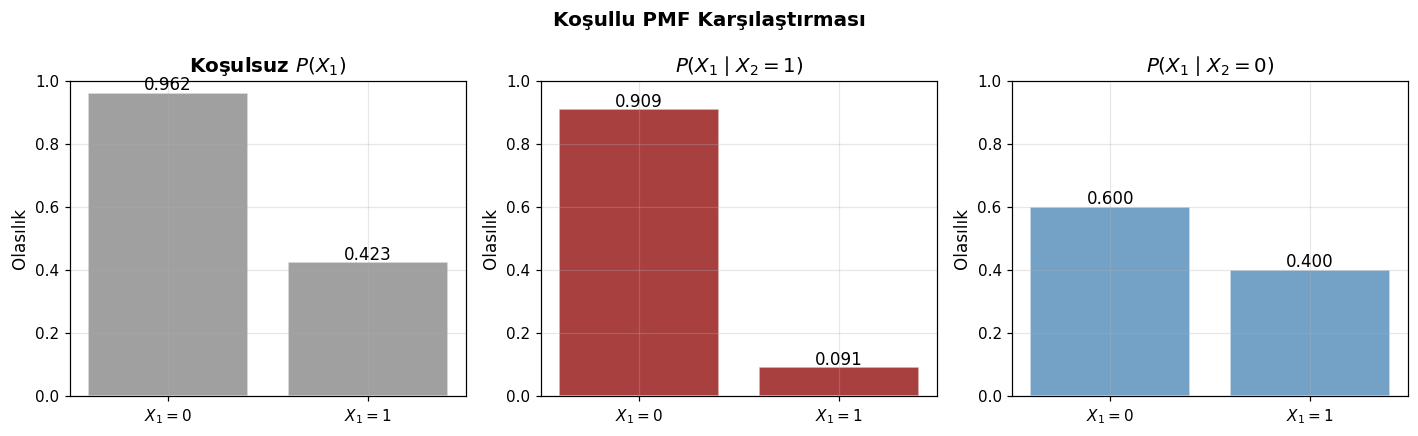

In [12]:
# ─── Görselleştirme: koşullu PMF'ler ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

cases = [
    (None,  [p00+p10, p01+p11], 'Koşulsuz $P(X_1)$', 'gray'),
    (1,     [joint_balls[(0,1)]/pX2_1, joint_balls[(1,1)]/pX2_1], '$P(X_1 \\mid X_2=1)$', DARK_RED),
    (0,     [joint_balls[(0,0)]/pX2_0, joint_balls[(1,0)]/pX2_0], '$P(X_1 \\mid X_2=0)$', 'steelblue'),
]

for ax, (cond_val, probs, title, color) in zip(axes, cases):
    ax.bar([0, 1], probs, color=color, alpha=0.75, edgecolor='white')
    for i, p in enumerate(probs):
        ax.text(i, p + 0.01, f'{p:.3f}', ha='center', fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['$X_1=0$', '$X_1=1$'])
    ax.set_ylim(0, 1.0); ax.set_ylabel('Olasılık')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Koşullu PMF Karşılaştırması', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='9'></a>
## 9. Koşullu Dağılımlar: Sürekli Durum

### Tanım
$X$ ve $Y$'nin birleşik olasılık fonksiyonu $f(x,y)$ iken, $Y = y$ verildiğinde ($f_Y(y) > 0$ için) $X$'in koşullu OYF'si:

$$f_{X|Y}(x|y) = \frac{f(x,y)}{f_Y(y)}$$

### Ders Örneği
$$f(x,y) = \frac{12}{5}x(2-x-y), \quad 0 < x < 1,\; 0 < y < 1$$

$$f_{X|Y}(x|y) = \frac{x(2-x-y)}{\int_0^1 x(2-x-y)\,dx} = \frac{6x(2-x-y)}{4-3y}$$

Normalizasyon: ∫∫ f(x,y) dx dy = 1.000000  (= 1 olmalı)


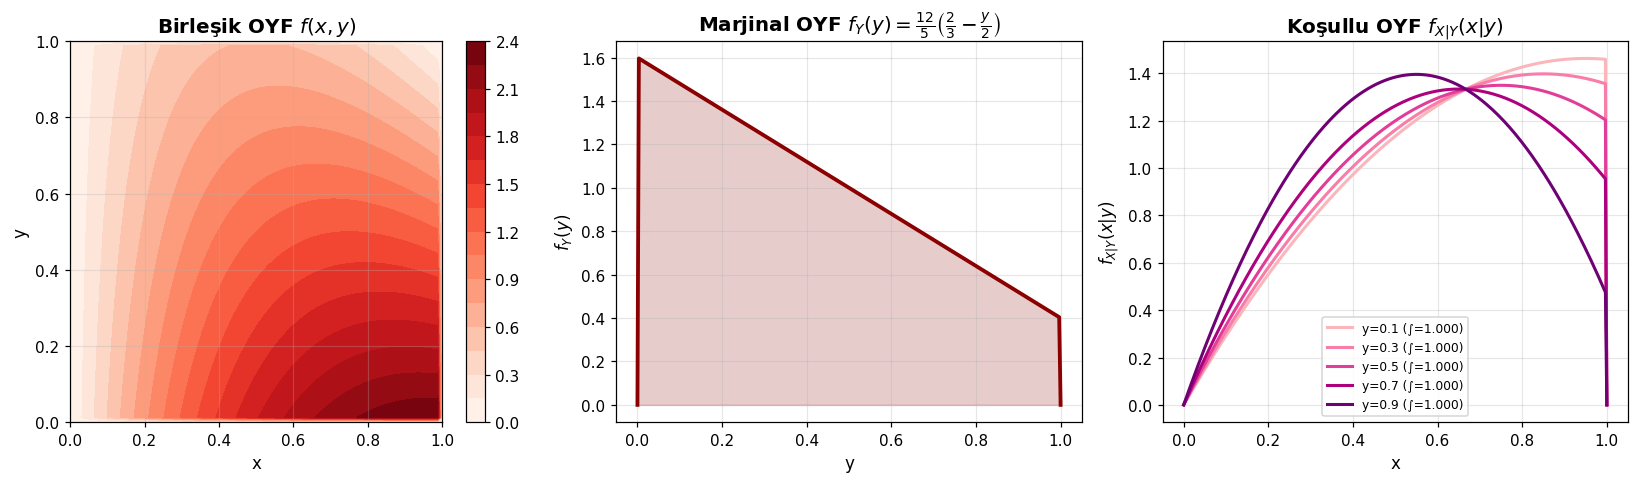


Koşullu OYF normalizasyon kontrolü:
  y=0.1: ∫₀¹ f_{X|Y}(x|0.1) dx = 1.000000
  y=0.3: ∫₀¹ f_{X|Y}(x|0.3) dx = 1.000000
  y=0.5: ∫₀¹ f_{X|Y}(x|0.5) dx = 1.000000
  y=0.7: ∫₀¹ f_{X|Y}(x|0.7) dx = 1.000000
  y=0.9: ∫₀¹ f_{X|Y}(x|0.9) dx = 1.000000


In [13]:
# ─── Sürekli koşullu dağılım ──────────────────────────────────────────────
def f_joint2(x, y):
    """f(x,y) = (12/5)*x*(2-x-y), 0<x<1, 0<y<1"""
    return np.where((0 < x) & (x < 1) & (0 < y) & (y < 1),
                    (12/5) * x * (2 - x - y), 0.0)

# Normalizasyon kontrolü
norm, _ = dblquad(lambda y, x: float(f_joint2(x, y)), 0, 1, 0, 1)
print(f'Normalizasyon: ∫∫ f(x,y) dx dy = {norm:.6f}  (= 1 olmalı)')

def f_Y2(y):
    """Marjinal: f_Y(y) = ∫₀¹ f(x,y) dx = (12/5)*(2/3 - y/2)"""
    return np.where((0 < y) & (y < 1), (12/5) * (2/3 - y/2), 0.0)

def f_cond(x, y):
    """Koşullu: f_{X|Y}(x|y) = 6x(2-x-y)/(4-3y)"""
    return np.where((0 < x) & (x < 1), 6*x*(2-x-y)/(4-3*y), 0.0)

# ─── Farklı y değerleri için koşullu dağılımlar ───────────────────────────
y_vals = [0.1, 0.3, 0.5, 0.7, 0.9]
xv = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Sol: birleşik OYF
xg, yg = np.meshgrid(np.linspace(0,1,80), np.linspace(0,1,80))
zg = f_joint2(xg, yg)
im = axes[0].contourf(xg, yg, zg, levels=20, cmap='Reds')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Birleşik OYF $f(x,y)$', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Orta: marjinal f_Y
yv = np.linspace(0, 1, 300)
axes[1].plot(yv, f_Y2(yv), color=DARK_RED, lw=2.5)
axes[1].fill_between(yv, f_Y2(yv), alpha=0.2, color=DARK_RED)
axes[1].set_title('Marjinal OYF $f_Y(y) = \\frac{12}{5}\\left(\\frac{2}{3}-\\frac{y}{2}\\right)$', fontweight='bold')
axes[1].set_xlabel('y'); axes[1].set_ylabel('$f_Y(y)$')

# Sağ: koşullu dağılımlar
colors = plt.cm.RdPu(np.linspace(0.3, 0.9, len(y_vals)))
for y0, col in zip(y_vals, colors):
    fc = f_cond(xv, y0)
    # normalizasyon doğrulama
    area, _ = quad(lambda x: f_cond(x, y0), 0, 1)
    axes[2].plot(xv, fc, color=col, lw=2, label=f'y={y0} (∫={area:.3f})')

axes[2].set_title('Koşullu OYF $f_{X|Y}(x|y)$', fontweight='bold')
axes[2].set_xlabel('x'); axes[2].set_ylabel('$f_{X|Y}(x|y)$')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nKoşullu OYF normalizasyon kontrolü:')
for y0 in y_vals:
    area, _ = quad(lambda x: float(f_cond(x, y0)), 0, 1)
    print(f'  y={y0}: ∫₀¹ f_{{X|Y}}(x|{y0}) dx = {area:.6f}')

<a id='10'></a>
## 10. Simülasyon ile Doğrulama — Kapsamlı Örnek

Üçgen bölgedeki birleşik dağılımı simüle ederek teorik sonuçları doğrulayalım:  
$f(x,y) = 2/9$, $x \geq 0,\; y \geq 0,\; x+y \leq 3$

Örneklem boyutu: 200,000

Nicelik                              Teorik   Simülasyon
E[X]                                1.00000      1.00122
E[Y]                                1.00000      1.00060
P(X < Y)                            0.50000      0.50018
P(X+Y > 2)                          0.11111      0.55536
P(X < 1)                            0.55556      0.55460


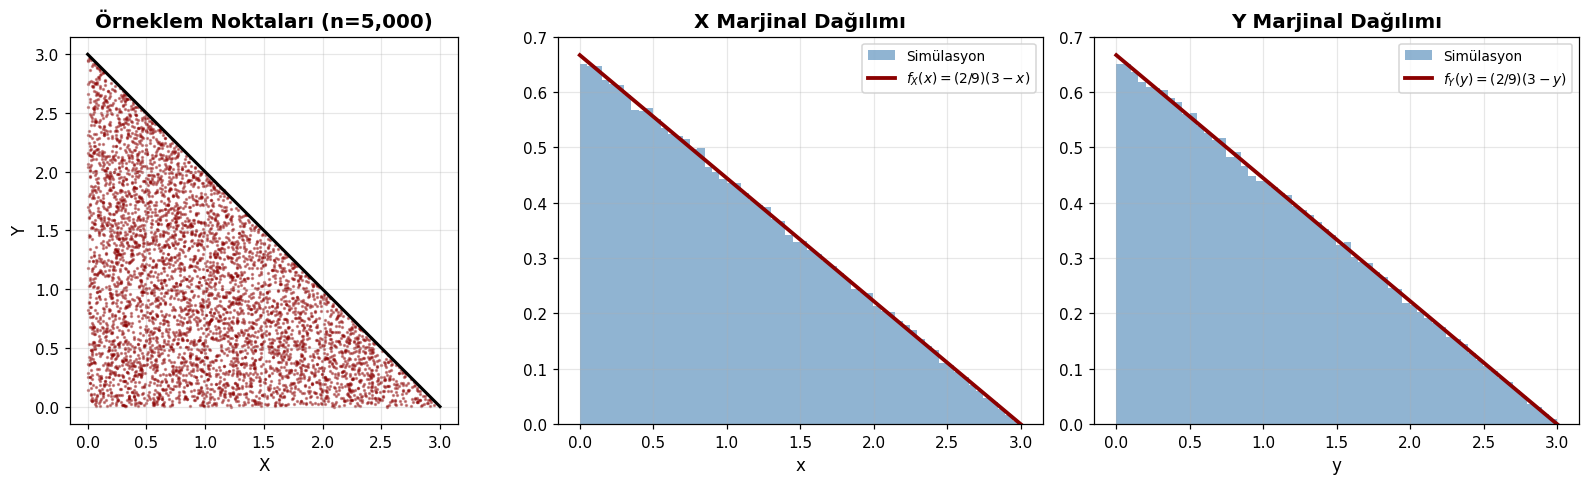

In [14]:
# ─── Reddedip-Kabul Örneklemesi (Rejection Sampling) ─────────────────────
np.random.seed(123)
N_target = 200_000

# [0,3]x[0,3] kutusundan örnekle, x+y≤3 koşulunu sağlayanları kabul et
candidates = np.random.uniform(0, 3, (N_target * 3, 2))
mask = candidates[:, 0] + candidates[:, 1] <= 3
samples = candidates[mask][:N_target]
X_samp, Y_samp = samples[:, 0], samples[:, 1]

print(f'Örneklem boyutu: {len(X_samp):,}')

# ─── Doğrulama tablosu ────────────────────────────────────────────────────
print('\n' + '=' * 60)
print(f'{"Nicelik":<30} {"Teorik":>12} {"Simülasyon":>12}')
print('=' * 60)

checks = [
    ('E[X]',         1.0,       X_samp.mean()),
    ('E[Y]',         1.0,       Y_samp.mean()),
    ('P(X < Y)',     0.5,       np.mean(X_samp < Y_samp)),
    ('P(X+Y > 2)',   5/9,       np.mean(X_samp + Y_samp > 2)),
    ('P(X < 1)',     5/9,       np.mean(X_samp < 1)),
]

for name, theory, sim in checks:
    print(f'{name:<30} {theory:>12.5f} {sim:>12.5f}')
print('=' * 60)

# ─── Görselleştirme ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Scatter
n_show = 5000
axes[0].scatter(X_samp[:n_show], Y_samp[:n_show], s=1.5, alpha=0.4, color=DARK_RED)
axes[0].plot([0,3],[3,0],'k-',lw=2)
axes[0].set_title(f'Örneklem Noktaları (n={n_show:,})', fontweight='bold')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
axes[0].set_aspect('equal')

# X marjinali
xv = np.linspace(0, 3, 300)
axes[1].hist(X_samp, bins=60, density=True, color='steelblue', alpha=0.6, label='Simülasyon')
axes[1].plot(xv, f_X(xv), color=DARK_RED, lw=2.5, label='$f_X(x)=(2/9)(3-x)$')
axes[1].set_title('X Marjinal Dağılımı', fontweight='bold')
axes[1].set_xlabel('x'); axes[1].legend(fontsize=9)

# Y marjinali
axes[2].hist(Y_samp, bins=60, density=True, color='steelblue', alpha=0.6, label='Simülasyon')
axes[2].plot(xv, f_Y(xv), color=DARK_RED, lw=2.5, label='$f_Y(y)=(2/9)(3-y)$')
axes[2].set_title('Y Marjinal Dağılımı', fontweight='bold')
axes[2].set_xlabel('y'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 📝 Özet Tablosu

| Kavram | Ayrık | Sürekli |
|---|---|---|
| **Birleşik dağılım** | $p_{X,Y}(x,y) = P(X=x, Y=y)$ | $f_{X,Y}(x,y) \geq 0$, $\iint = 1$ |
| **Marjinal** | $p_X(x) = \sum_y p(x,y)$ | $f_X(x) = \int f(x,y)\,dy$ |
| **Koşullu** | $p_{X|Y}(x|y) = p(x,y)/p_Y(y)$ | $f_{X|Y}(x|y) = f(x,y)/f_Y(y)$ |
| **Bağımsızlık** | $p(x,y) = p_X(x)p_Y(y)$ | $f(x,y) = f_X(x)f_Y(y)$ |
| **Toplam (konvolüsyon)** | — | $f_{X+Y}(z) = \int f_X(x)f_Y(z-x)\,dx$ |

---
*MAT204 — Mühendisler İçin Olasılık ve İstatistik — Dr. Haydar Kılıç*